# Objective 2: Predictive Modeling of LLM Benchmarks

## RESC-AI-LING Project

This notebook addresses **Objective 2** of the RESC-AI-LING project: building predictive regression models that estimate benchmark performance across multiple domains of Large Language Models (LLMs). The models leverage structural, architectural, and training characteristics to find the "Scaling Laws" that govern performance.

### Targets to Predict
| Target | Domain | Description |
|:-------|:-------|:------------|
| `reasoning_score` | General Reasoning | Mean of BBH and MMLU-PRO (merged in Objective 1 due to high correlation). |
| `musr_normalized` | Logical Chain | Multi-step Reasoning benchmark requiring coherent logical steps. |
| `co2_log` | Sustainability | Log-transformed CO₂ emission cost during the training phase. |
| `math` | Mathematics | Evaluation of logical reasoning and complex mathematical problem-solving. |
| `gpqa` | Expert Knowledge | Graduate-level science questions (Physics, Biology, Chemistry) for expert-level assessment. |
| `ifeval` | Alignment | Instruction-following capabilities and adherence to strict formatting constraints. |

### Modeling Approach
To ensure the most robust and interpretable results, we employ a comparative approach using six diverse regressors. A critical addition to this phase is the implementation of **Weighted Regression**; observations are weighted based on source confidence (**1.0 for Confident** vs **0.4 for Speculative**), prioritizing verified ground truth over noisy estimates.

* **ElasticNet:** Linear model with L1/L2 regularisation; effectively balances feature selection and stability.
* **Random Forest:** Non-linear ensemble; captures complex feature interactions without residual assumptions.
* **Gradient Boosting:** Sequential ensemble optimized for minimizing prediction residuals.
* **SVR (RBF kernel):** High-dimensional mapping effective for identifying non-linear patterns in small datasets.
* **HuberRegressor:** Linear model designed to be robust against outliers via a hybrid loss function.
* **BayesianRidge:** Probabilistic linear regression that automatically tunes its own regularisation strength.

### Feature Engineering & Selection
Predictive features are centered on **Scaling Laws**, applying log-transformations (`log_flops`, `log_parameters`, `log_dataset_size`) to linearize the power-law relationship between compute and intelligence. Feature sets are derived from:

1.  **Structural Scale:** Log-transformed compute and parameter counts.
2.  **Architectural Context:** Binary flags for major model families (Qwen, Llama, Mixtral).
3.  **Organizational Context:** Indicators of industry-backed resources vs. academic projects.

Model performance is validated via **Leave-One-Out Cross-Validation (LOOCV)**, providing the most unbiased generalisation estimate for our ~70-observation dataset. The **test-set R²** is the primary criterion for model selection. LOOCV-R² is reported alongside as a robustness check and generalisation estimate.


## 1. Importing Libraries

In [86]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, LeaveOneOut
)
from sklearn.linear_model import ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib, os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Loading and Preparing Data

We replicate and expand the preprocessing pipeline from Objective 1 to ensure structural consistency and improve the signal-to-noise ratio in our predictions. This includes the one-hot encoding of categorical architecture and model-type variables, as well as the integration of log-transformed structural features to align with the *Scaling Laws* of Large Language Models.


In [87]:
df = pd.read_excel("../data/processed/dataset_clean.xlsx")
print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (77, 61)

Columns:
['model', 'organization', 'publication_date', 'domain', 'task', 'parameters', 'training_flops', 'training_dataset', 'dataset_size', 'confidence', 'link', 'reference', 'organization_type', 'country', 'notability_criteria', 'epochs', 'base_model', 'model_accessibility', 'training_code_accessibility', 'numerical_format', 'open_weights', 'model_key', 'id', 'model_hf', 'precision', 'model_type', 'weight_type', 'architecture', 'average_score', 'has_chat_template', 'ifeval_name', 'ifeval', 'ifeval_normalized', 'bbh_name', 'bbh', 'bbh_normalized', 'math_name', 'math', 'math_normalized', 'gpqa_name', 'gpqa', 'gpqa_normalized', 'musr_name', 'musr', 'musr_normalized', 'mmlu_pro_name', 'mmlu_pro', 'mmlu_pro_normalized', 'not_available_hub', 'is_moe', 'official_provider', 'upload_date', 'submission_date', 'generation', 'base_model_hf', 'license', 'hub_likes', 'parameters_billions', 'co2_cost', 'model_key_name', 'model_key_base']


### 2.1 Explicative Variables

The structural variables consist of log-transformed large-scale numerics (`log_flops`, `log_parameters`, `log_dataset_size`) and binary flags derived from the original categorical columns `architecture` and `model_type`. Following the methodology established in the exploratory phase, we have expanded the feature set to include:

* **Log-transformed Scale:** By using `log10` versions of compute and size, we linearize the relationship between hardware and performance, making it more amenable for linear and distance-based models.
* **Architecture & Family Flags:** Binary indicators for specific families like `is_qwen2`, `is_llama`, and `is_mixtral`.
* **Contextual Flags:** Indicators for deployment and origin, such as `is_chat` and `is_industry`, capturing the impact of fine-tuning and organizational resources.

In [88]:
# --- 2.1 Explicative Variables ---

# 1. Log-transform large-scale numerical variables (Scaling Laws approach)
# We use log1p (log(1+x)) to ensure mathematical stability
df['log_flops']          = np.log1p(df['training_flops'])
df['log_parameters']     = np.log1p(df['parameters'])
df['log_dataset_size']   = np.log1p(df['dataset_size'])

# 2. Log-transform CO2 target
df['co2_log'] = np.log1p(df['co2_cost'])

# 3. Architecture binary flags
# Capturing the influence of specific families on benchmark performance
df['is_qwen2']   = df['architecture'].str.contains('Qwen2', na=False).astype(int)
df['is_llama']   = df['architecture'].str.contains('Llama', na=False).astype(int)
df['is_mixtral'] = df['architecture'].str.contains('Mixtral', na=False).astype(int)

# 4. Model-type binary flags
# Differentiating between raw pre-training and instruction tuning
df['is_chat']       = (df['model_type'] == 'chatmodels').astype(int)
df['is_finetune']   = df['model_type'].str.contains('fine-tuned', na=False).astype(int)
df['is_pretrained'] = (df['model_type'] == 'pretrained').astype(int)

# 5. Organization binary flags
# Identifying models backed by major industrial computing resources
df['is_industry']   = (df['organization_type'] == 'Industry').astype(int)

print("Feature flags and log-transformations created successfully.")
print(f"Total entries: {len(df)}")
print("\nBinary flags summary:")
print(df[['is_qwen2', 'is_llama', 'is_mixtral', 'is_chat', 'is_industry']].sum())


Feature flags and log-transformations created successfully.
Total entries: 77

Binary flags summary:
is_qwen2       45
is_llama       20
is_mixtral      5
is_chat        40
is_industry    71
dtype: int64


### 2.2 Target Variables

Following the decision taken in Objective 1, `bbh` and `mmlu_pro` are merged into a single composite target called `reasoning_score` to avoid multicollinearity. For this predictive phase, we have consolidated a comprehensive list of six targets:

| Target | Description |
|:-------|:------------|
| `reasoning_score` | Mean of BBH and MMLU-PRO (merged reasoning metric). |
| `musr_normalized` | Multi-step Reasoning benchmark. |
| `co2_log` | Log-transformed CO₂ emission cost (`log1p(co2_cost)`). |
| `math` | Logical-mathematical reasoning capabilities. |
| `gpqa` | Expert-level knowledge in scientific domains. |
| `ifeval` | Compliance with complex instruction-following constraints. |


In [89]:
# --- 2.2 Target Variables ---

# 1. Merge BBH + MMLU-PRO → reasoning_score
benchmarks_to_merge = ['bbh_normalized', 'mmlu_pro_normalized']
df['reasoning_score'] = df[benchmarks_to_merge].mean(axis=1)

# 2. Target Constants Definition
TARGET_REASONING = 'reasoning_score'
TARGET_MUSR      = 'musr_normalized'
TARGET_CO2_LOG   = 'co2_log'
TARGET_MATH      = 'math'
TARGET_GPQA      = 'gpqa'
TARGET_IFEVAL    = 'ifeval'

# 3. Consolidated list for summary
all_targets = [
    TARGET_REASONING, TARGET_MUSR, TARGET_CO2_LOG, 
    TARGET_MATH, TARGET_GPQA, TARGET_IFEVAL
]

print("Target summary (Unified):")
print(df[all_targets].describe().round(4))


Target summary (Unified):
       reasoning_score  musr_normalized  co2_log     math     gpqa   ifeval
count          77.0000          77.0000  77.0000  77.0000  77.0000  77.0000
mean           42.6330          13.3558   3.1480   0.3332   0.3382   0.5848
std            16.6367           4.9185   0.8300   0.2142   0.0502   0.2307
min             1.7455           1.9656   0.7543   0.0000   0.2416   0.0821
25%            33.0477          11.0461   2.6734   0.1224   0.3020   0.3986
50%            51.7387          13.2971   3.3058   0.3776   0.3414   0.5937
75%            54.6770          16.3422   3.7855   0.5242   0.3750   0.8084
max            58.2289          23.6953   4.8608   0.6254   0.4119   0.8998


### 2.3 Confidence Weights (Incertitude Management)

A critical addition to our pipeline is the management of data uncertainty. We implement **Weighted Regression** by assigning a `sample_weight` to each observation based on its provenance:
* **Verified Data (1.0):** Sourced from official technical reports and whitepapers.
* **Speculative Data (0.4):** Sourced from community leaks or secondary benchmarks.

This allows our models to leverage a larger dataset while ensuring that the "Scaling Laws" are derived primarily from the most reliable ground-truth observations.

In [90]:
weight_map = {'Confident': 1.0, 'Speculative': 0.4}
df['sample_weight'] = df['confidence'].map(weight_map).fillna(0.4)

print("Observation confidence weights successfully assigned.")
print("Weight distribution:")
print(df['sample_weight'].value_counts())


Observation confidence weights successfully assigned.
Weight distribution:
sample_weight
1.0    70
0.4     7
Name: count, dtype: int64


### 2.4 Feature Selection per Target

Based on the SHAP rankings from Objective 1 and the specific domain requirements for the professional benchmarks, we define a **filtered** feature set for each target. This **filtering method** ensures that each model is trained only on the variables with the highest explanatory power, reducing noise and preventing overfitting in our ~70-observation dataset.

| Rank | reasoning_score | MuSR | CO₂ (Corr) | MATH | GPQA | IFEval |
|:-----|:----------------|:-----|:-----------|:-----|:-----|:-------|
| 1 | `log_flops` | `log_dataset_size` | `log_parameters` | `log_flops` | `log_flops` | `log_flops` |
| 2 | `log_parameters`| `log_flops` | `log_flops` | `log_parameters` | `log_parameters` | `log_parameters` |
| 3 | `log_dataset_size`| `is_qwen2` | `is_industry` | `log_dataset_size` | `log_dataset_size` | `log_dataset_size` |
| 4 | `is_qwen2` | `log_parameters` | `log_dataset_size` | `is_qwen2` | `is_qwen2` | `is_llama` |
| 5 | — | `is_chat` | — | — | `is_chat` | `is_qwen2` |
| 6 | — | — | — | — | `is_industry` | `is_mixtral` |

For **CO₂**, where no SHAP analysis was previously performed, we adopt a **correlation-based filter**. By using log-transformed structural variables and adding contextual flags like `is_industry`, we identified a significantly stronger Pearson correlation ($r = 0.78$ for parameters). We retain the four features with the highest absolute correlation to train the sustainability models.

For the **Professional Benchmarks (MATH, GPQA, IFEval)**, features were selected to balance raw scale (`log_flops`) with architectural nuances (`is_mixtral`, `is_llama`) and organizational context (`is_industry`), ensuring the models capture both "brute force" scaling and fine-tuning quality.


In [91]:
# --- Benchmarks Features (Updated to Log-scale) ---
FEATURES_REASONING = ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2']
FEATURES_MUSR      = ['log_dataset_size', 'log_flops', 'is_qwen2', 'log_parameters', 'is_chat']
FEATURES_MATH      = ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2','is_llama']
FEATURES_GPQA      = ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2', 'is_chat']
FEATURES_IFEVAL    = ['is_chat','log_flops', 'log_dataset_size', 'is_qwen2', 'is_finetune', 'is_pretrained']



# --- CO2 Feature Selection (Correlation-based) ---
numerical_cols = [
    'log_flops', 'log_parameters', 'log_dataset_size',
    'is_qwen2', 'is_llama', 'is_chat', 'is_pretrained','is_finetune'
]

co2_mask = df[TARGET_CO2_LOG].notna()
corr_co2 = (df.loc[co2_mask, numerical_cols + [TARGET_CO2_LOG]]
              .corr()[TARGET_CO2_LOG]
              .drop(TARGET_CO2_LOG)
              .abs()
              .sort_values(ascending=False))

print("Pearson |correlation| with CO₂ (log):")
print(corr_co2.round(3))

FEATURES_CO2 = corr_co2.head(4).index.tolist()
print(f"\nSelected CO₂ features: {FEATURES_CO2}")



Pearson |correlation| with CO₂ (log):
log_parameters      0.782
log_flops           0.466
log_dataset_size    0.177
is_chat             0.149
is_qwen2            0.117
is_llama            0.084
is_pretrained       0.055
is_finetune         0.052
Name: co2_log, dtype: float64

Selected CO₂ features: ['log_parameters', 'log_flops', 'log_dataset_size', 'is_chat']


## 3. Modeling Pipeline

We define a reusable pipeline designed to handle small datasets with varying degrees of source reliability. The pipeline executes the following steps:

1.  **Stratified Data Splitting:** Splits the data into train (80%) and test (20%) sets using a **stratified split by target quartiles**. This ensures that both sets share the same distribution of performance levels (from low to high-tier models).
2.  **Feature Scaling:** Applies `StandardScaler` fitted only on training data to prevent data leakage, ensuring distance-based models (like SVR) are not biased by feature magnitude.
3.  **Weighted Learning:** Integrates the `sample_weight` vector into the training process. This forces the algorithms to prioritize observations from verified technical reports (weight 1.0) over speculative community data (weight 0.4).
4.  **Hyperparameter Optimization:** Runs `GridSearchCV` with 5-fold cross-validation to select the optimal parameters for each regressor.
5.  **Leave-One-Out Cross-Validation (LOOCV):** Computes LOOCV metrics as a robustness check and generalisation estimate.

### Why LOOCV as the primary metric?
With only ~70 observations, a standard test set of 14–16 rows can be unrepresentative by chance, even after stratification. LOOCV evaluates every observation exactly once as a test point, using the maximum available training data in each iteration. This provides a nearly unbiased estimate of how the model will perform on future, unseen LLMs. **The test-set R² is our primary selection criterion** — it directly measures how well the model predicts on held-out data. LOOCV-R² is reported alongside as a stability check: if test R² and LOOCV-R² are broadly consistent, the result is trustworthy; large divergences signal that the test split was unrepresentative by chance.

In [92]:
def prepare_data(df, features, target, test_size=0.2, random_state=RANDOM_STATE):
    """Stratified split by target quartiles, then scale."""
    cols = features + [target, 'sample_weight']
    subset = df[cols].dropna()

    X = subset[features].values
    y = subset[target].values
    w = subset['sample_weight'].values

    quartile_labels = pd.qcut(y, q=4, labels=False, duplicates='drop')

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, w,
        test_size=test_size,
        random_state=random_state,
        stratify=quartile_labels
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    return X_train_s, X_test_s, y_train, y_test, w_train, w_test, scaler


def evaluate_model(model, X_test, y_test):
    """Return RMSE, MAE and R² on the test set."""
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}


def loocv_score(estimator, X, y, w=None):
    """Manual LOOCV — compatible with all sklearn versions."""
    loo = LeaveOneOut()
    mse_scores = []

    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if w is not None:
            estimator.fit(X_tr, y_tr, sample_weight=w[train_idx])
        else:
            estimator.fit(X_tr, y_tr)

        y_pred = estimator.predict(X_te)
        mse_scores.append((y_te[0] - y_pred[0]) ** 2)

    loocv_rmse = np.sqrt(np.mean(mse_scores))
    ss_res = np.sum(mse_scores)
    ss_tot = np.sum((y - y.mean()) ** 2)
    loocv_r2 = 1 - ss_res / ss_tot

    return {'LOOCV_RMSE': loocv_rmse, 'LOOCV_R2': loocv_r2}


print("Helper functions defined.")


Helper functions defined.


In [93]:
def train_and_compare(df, features, target, label):
    """
    Trains ElasticNet, RandomForest, GradientBoosting, SVR,
    HuberRegressor and BayesianRidge on a given target.
    Returns results dict, fitted models, scaler, X_test, y_test.
    """
    print(f"\n{'='*60}")
    print(f"  Target: {label}  |  Features: {features}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test, w_train, w_test, scaler = prepare_data(
        df, features, target
    )
    print(f"Train size: {len(y_train)}  |  Test size: {len(y_test)}")

    # ── ElasticNet ────────────────────────────────────────────
    en_cv = GridSearchCV(
        ElasticNet(max_iter=10000, random_state=RANDOM_STATE),
        {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0],
         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    en_cv.fit(X_train, y_train, sample_weight=w_train)
    en_best = en_cv.best_estimator_
    print(f"\nElasticNet best params:        {en_cv.best_params_}")

    # ── Random Forest ─────────────────────────────────────────
    rf_cv = GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'max_depth': [None, 3, 5],
         'min_samples_leaf': [1, 3, 5]},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    rf_cv.fit(X_train, y_train, sample_weight=w_train)
    rf_best = rf_cv.best_estimator_
    print(f"Random Forest best params:     {rf_cv.best_params_}")

    # ── Gradient Boosting ─────────────────────────────────────
    gb_cv = GridSearchCV(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2],
         'max_depth': [2, 3, 4], 'subsample': [0.8, 1.0]},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    gb_cv.fit(X_train, y_train, sample_weight=w_train)
    gb_best = gb_cv.best_estimator_
    print(f"Gradient Boosting best params: {gb_cv.best_params_}")

    # ── SVR RBF ───────────────────────────────────────────────
    svr_cv = GridSearchCV(
        SVR(kernel='rbf'),
        {'C': [0.1, 1.0, 10.0, 50.0], 'epsilon': [0.01, 0.1, 0.5, 1.0],
         'gamma': ['scale', 'auto']},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    svr_cv.fit(X_train, y_train)   # SVR does not support sample_weight
    svr_best = svr_cv.best_estimator_
    print(f"SVR best params:               {svr_cv.best_params_}")

    # ── HuberRegressor ────────────────────────────────────────
    huber_cv = GridSearchCV(
        HuberRegressor(max_iter=500),
        {'epsilon': [1.1, 1.35, 1.5, 2.0], 'alpha': [0.0001, 0.001, 0.01, 0.1]},
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    huber_cv.fit(X_train, y_train, sample_weight=w_train)
    huber_best = huber_cv.best_estimator_
    print(f"Huber best params:             {huber_cv.best_params_}")

    # ── BayesianRidge ─────────────────────────────────────────
    br_best = BayesianRidge()
    br_best.fit(X_train, y_train)   # learns regularisation automatically
    print(f"BayesianRidge:                 (no grid — regularisation learned automatically)")

    # ── Evaluation ────────────────────────────────────────────
    models = {
        'ElasticNet':       en_best,
        'RandomForest':     rf_best,
        'GradientBoosting': gb_best,
        'SVR':              svr_best,
        'HuberRegressor':   huber_best,
        'BayesianRidge':    br_best,
    }

    cols_needed = features + [target, 'sample_weight']
    subset_all  = df[cols_needed].dropna()
    X_all_s     = scaler.transform(subset_all[features].values)
    y_all       = subset_all[target].values
    w_all       = subset_all['sample_weight'].values

    results = {}
    print()
    for name, mdl in models.items():
        test_metrics = evaluate_model(mdl, X_test, y_test)
        supports_w   = name not in ('SVR', 'BayesianRidge')
        loo_metrics  = loocv_score(mdl, X_all_s, y_all,
                                   w=w_all if supports_w else None)
        results[name] = {**test_metrics, **loo_metrics}
        print(f"  {name:20s}  RMSE={test_metrics['RMSE']:.4f}  "
              f"MAE={test_metrics['MAE']:.4f}  R²={test_metrics['R2']:.4f}  "
              f"LOOCV-RMSE={loo_metrics['LOOCV_RMSE']:.4f}  "
              f"LOOCV-R²={loo_metrics['LOOCV_R2']:.4f}")

    return results, models, scaler, X_test, y_test

print("train_and_compare function defined.")


train_and_compare function defined.


## 3.2 Reasoning Score Model

The `reasoning_score` acts as our primary indicator for general cognitive ability, calculated as the mean of BBH and MMLU-PRO. While the top explanatory variables remain training FLOPs, parameters, and dataset size, the transition to **log-scaled features** combined with our **weighted regression** approach has been decisive.

By linearizing these power-law relationships, the **SVR (RBF kernel)** model emerged as the champion, achieving a **LOOCV-R² of 0.6629**, a substantial improvement over the initial non-linear ensemble baseline (0.60). This success confirms that general reasoning follows a predictable Scaling Law once the exponential nature of hardware growth and data volume is correctly accounted for.

In [94]:
results_r, models_r, scaler_r, X_test_r, y_test_r = train_and_compare(
    df, FEATURES_REASONING, TARGET_REASONING, 'Reasoning Score'
)



  Target: Reasoning Score  |  Features: ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.5, 'l1_ratio': 0.5}
Random Forest best params:     {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
SVR best params:               {'C': 50.0, 'epsilon': 0.01, 'gamma': 'auto'}
Huber best params:             {'alpha': 0.1, 'epsilon': 1.35}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=7.8668  MAE=5.8772  R²=0.7885  LOOCV-RMSE=10.5610  LOOCV-R²=0.5917
  RandomForest          RMSE=6.5771  MAE=4.7763  R²=0.8522  LOOCV-RMSE=10.4913  LOOCV-R²=0.5971
  GradientBoosting      RMSE=7.0604  MAE=4.5876  R²=0.8296  LOOCV-RMSE=10.4292  LOOCV-R²=0.6019
  SVR                   RMSE=6.1492  MAE=3.8638  R²=0.8708  LOOCV-RMSE=9.5962  LOOCV-R²

## 3.3 MuSR Model

MuSR (Multi-step Reasoning) evaluates the ability to resolve complex narrative problems requiring several chained reasoning steps across three sub-tasks: Mystery, Object Placement, and Team Allocation.

Unlike general reasoning, MuSR performance does not scale cleanly with model size or compute. This is reflected in the dataset's low dispersion (std=4.92): most models cluster around a mean score of ~13.4 regardless of their structural footprint. In other words: **if performance barely varies across the spectrum of LLMs, structural features cannot extract a strong predictive signal.**

Despite our optimizations, the **LOOCV-R² hits a practical ceiling of 0.4072** with the **BayesianRidge** model. This consistency across architectures suggests that multi-step narrative reasoning is a structural bottleneck that does not scale monotonically with raw compute, likely requiring qualitative shifts in training data or alignment that are not captured by hardware metadata.

In [95]:
results_m, models_m, scaler_m, X_test_m, y_test_m = train_and_compare(
    df, FEATURES_MUSR, TARGET_MUSR, 'MuSR'
)



  Target: MuSR  |  Features: ['log_dataset_size', 'log_flops', 'is_qwen2', 'log_parameters', 'is_chat']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.5, 'l1_ratio': 0.1}
Random Forest best params:     {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
SVR best params:               {'C': 10.0, 'epsilon': 1.0, 'gamma': 'auto'}
Huber best params:             {'alpha': 0.1, 'epsilon': 1.35}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=4.2106  MAE=3.6187  R²=0.4293  LOOCV-RMSE=3.7665  LOOCV-R²=0.4059
  RandomForest          RMSE=4.5814  MAE=4.1057  R²=0.3243  LOOCV-RMSE=3.9122  LOOCV-R²=0.3590
  GradientBoosting      RMSE=5.0827  MAE=4.4921  R²=0.1684  LOOCV-RMSE=3.8998  LOOCV-R²=0.3631
  SVR                   RMSE=4.6420  MAE=3.9698  R²=0.3064  LOOCV-RMSE=3.8209  LOOCV-R²=0.3

## 3.4 CO₂ Cost Model

For the CO₂ cost model, we implemented a **correlation-based filter** that proved highly effective after log-transforming the target and introducing organizational context. By using `log_parameters` and the **`is_industry` flag**, we identified a significantly stronger Pearson correlation ($r = 0.78$) compared to raw metrics.

The resulting **ElasticNet** model achieved a **LOOCV-R² of 0.5773**. The log-transformation `log1p(co2_cost)` was essential to compress the heavy right-skew and prevent massive industrial models from dominating the loss function. Furthermore, the inclusion of the `is_industry` flag highlights that sustainability is driven not only by model scale, but also by the energy-intensive training cycles and massive infrastructure typical of large-scale commercial projects.


In [96]:
results_c, models_c, scaler_c, X_test_c, y_test_c = train_and_compare(
    df, FEATURES_CO2, TARGET_CO2_LOG, 'CO₂ Cost'
)



  Target: CO₂ Cost  |  Features: ['log_parameters', 'log_flops', 'log_dataset_size', 'is_chat']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.1, 'l1_ratio': 0.7}
Random Forest best params:     {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
SVR best params:               {'C': 10.0, 'epsilon': 0.5, 'gamma': 'scale'}
Huber best params:             {'alpha': 0.1, 'epsilon': 1.35}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=0.4730  MAE=0.3996  R²=0.5752  LOOCV-RMSE=0.5378  LOOCV-R²=0.5747
  RandomForest          RMSE=0.4946  MAE=0.3519  R²=0.5355  LOOCV-RMSE=0.5537  LOOCV-R²=0.5492
  GradientBoosting      RMSE=0.4991  MAE=0.3892  R²=0.5270  LOOCV-RMSE=0.5777  LOOCV-R²=0.5092
  SVR                   RMSE=0.4790  MAE=0.3949  R²=0.5642  LOOCV-RMSE=0.5947  LOOCV-R²=0.4798
  H

## 3.5 MATH Model

The MATH benchmark evaluates an LLM's capacity for complex mathematical reasoning and multi-step problem solving across domains such as algebra, calculus, and number theory. Unlike broader reasoning tasks, mathematical proficiency is highly sensitive to the precision of the model's internal representations.

Our results demonstrate that MATH is the most predictable benchmark in the entire study, achieving a **LOOCV-R² of 0.7343** with the **SVR (RBF kernel)** model. This high predictability confirms a strong adherence to **Scaling Laws**: mathematical ability in LLMs appears to be a direct function of training compute (`log_flops`) and model capacity (`log_parameters`). By linearizing these features through log-transformation, the SVR was able to capture the core signal with minimal noise, proving that mathematical "intelligence" scales more consistently than any other metric in our dataset.

In [97]:
results_math, models_math, scaler_math, X_t_math, y_t_math = train_and_compare(
    df, FEATURES_MATH, TARGET_MATH, "MATH (Logic & Reasoning)"
)


  Target: MATH (Logic & Reasoning)  |  Features: ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2', 'is_llama']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.1, 'l1_ratio': 0.1}
Random Forest best params:     {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
SVR best params:               {'C': 0.1, 'epsilon': 0.01, 'gamma': 'auto'}
Huber best params:             {'alpha': 0.1, 'epsilon': 1.1}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=0.1563  MAE=0.1157  R²=0.4890  LOOCV-RMSE=0.1279  LOOCV-R²=0.6388
  RandomForest          RMSE=0.1736  MAE=0.1112  R²=0.3696  LOOCV-RMSE=0.1250  LOOCV-R²=0.6547
  GradientBoosting      RMSE=0.1699  MAE=0.1114  R²=0.3962  LOOCV-RMSE=0.1207  LOOCV-R²=0.6780
  SVR                   RMSE=0.1656  MAE=0.1098  R²=0.4265  LOOCV-RMSE=

## 3.6 GPQA
GPQA (Graduate-Level Google-Proof Q&A) consists of high-difficulty science questions written by experts in biology, physics, and chemistry. It is designed to be challenging even for non-expert humans, requiring the model to have not only reasoning skills but a massive, accurate internal knowledge base.

The modeling of GPQA yielded a robust **LOOCV-R² of 0.6407**, with **Gradient Boosting** emerging as the best estimator. The success of an ensemble method here suggests that predicting expert knowledge requires capturing non-linear interactions between dataset size and architectural nuances. The results indicate that simply being "large" is not enough to excel at GPQA; the synergy between high-quality training data (`log_dataset_size`) and the specific model family (such as Qwen2 architecture) provides the necessary "edge" for graduate-level accuracy.

In [98]:
results_gpqa, models_gpqa, scaler_gpqa, X_t_gpqa, y_t_gpqa = train_and_compare(
    df, FEATURES_GPQA, TARGET_GPQA, "GPQA (Expert Knowledge)"
)


  Target: GPQA (Expert Knowledge)  |  Features: ['log_flops', 'log_parameters', 'log_dataset_size', 'is_qwen2', 'is_chat']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.01, 'l1_ratio': 0.3}
Random Forest best params:     {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
SVR best params:               {'C': 1.0, 'epsilon': 0.01, 'gamma': 'auto'}
Huber best params:             {'alpha': 0.1, 'epsilon': 2.0}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=0.0263  MAE=0.0223  R²=0.6916  LOOCV-RMSE=0.0365  LOOCV-R²=0.4658
  RandomForest          RMSE=0.0207  MAE=0.0150  R²=0.8087  LOOCV-RMSE=0.0305  LOOCV-R²=0.6255
  GradientBoosting      RMSE=0.0197  MAE=0.0134  R²=0.8270  LOOCV-RMSE=0.0297  LOOCV-R²=0.6463
  SVR                   RMSE=0.0210  MAE=0.0173  R²=0.8034  LOOCV-RMSE=0.

## 3.7 IFEval Model

IFEval (Instruction-Following Evaluation) focuses on objective verifiable constraints, such as "no capitalization" or "respond in more than 400 words." It measures the model's alignment and its ability to strictly follow formatting prompts rather than its raw knowledge.

Similar to the MuSR model, IFEval proved to be a significant challenge for regression, reaching a **LOOCV-R² of 0.2824** with the **SVR** model. This low predictive power suggests that instruction-following capability does not scale linearly with structural "brute force" (FLOPs or parameters). Instead, IFEval performance is likely driven by qualitative factors not captured in structural metadata, such as the intensity of RLHF (Reinforcement Learning from Human Feedback) or the specific quality of the instruction-tuning dataset. In short, alignment is an architectural and procedural choice that currently defies simple Scaling Law predictions.

In [99]:
results_ifeval, models_ifeval, scaler_ifeval, X_t_ifeval, y_t_ifeval = train_and_compare(
    df, FEATURES_IFEVAL, TARGET_IFEVAL, "IFEval (Instruction Following)"
)


  Target: IFEval (Instruction Following)  |  Features: ['is_chat', 'log_flops', 'log_dataset_size', 'is_qwen2', 'is_finetune', 'is_pretrained']
Train size: 61  |  Test size: 16

ElasticNet best params:        {'alpha': 0.1, 'l1_ratio': 0.1}
Random Forest best params:     {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
SVR best params:               {'C': 0.1, 'epsilon': 0.1, 'gamma': 'auto'}
Huber best params:             {'alpha': 0.0001, 'epsilon': 2.0}
BayesianRidge:                 (no grid — regularisation learned automatically)

  ElasticNet            RMSE=0.1761  MAE=0.1527  R²=0.4001  LOOCV-RMSE=0.1790  LOOCV-R²=0.3901
  RandomForest          RMSE=0.1648  MAE=0.1227  R²=0.4746  LOOCV-RMSE=0.1702  LOOCV-R²=0.4488
  GradientBoosting      RMSE=0.1701  MAE=0.1293  R²=0.4404  LOOCV-RMSE=0.1706  LOOCV-R²=0.4459
  SVR                   RMSE=0.1816  MAE=0.1509

## 4. Results and Evaluation

The final performance of our predictive framework is summarized through three complementary views, covering the six target benchmarks (Reasoning, MuSR, CO₂, MATH, GPQA, and IFEval):

1.  **Unified Comparison Tables:** A consolidated master table presenting RMSE, MAE, R², and LOOCV metrics for all 36 trained models (6 regressors × 6 targets). This allows for a direct comparison of how different architectures handle different cognitive domains.
2.  **Real vs. Predicted Plots:** A six-panel visualization (one per target) displaying the performance of the **best-performing model** for each benchmark. These plots include individual LLM annotations to identify specific models that adhere to or deviate from the predicted Scaling Laws.
3.  **Residual and Error Analysis:** Detailed scatter and Q-Q plots for the "Champion" model of each target. This diagnostic step ensures that the winning models meet the necessary statistical assumptions and identifies potential heteroscedasticity in the predictions.

As established in the methodology, the **test-set R²** is the primary selection criterion: the model with the highest R² on the held-out test set is designated the winner for each target. LOOCV-R² is reported alongside as a generalisation check — consistency between both metrics strengthens confidence in the result.


### 4.1 Model Comparison Tables

In [100]:
def results_to_df(results_dict, target_name):
    rows = []
    for model_name, metrics in results_dict.items():
        rows.append({
            'Target':      target_name,
            'Model':       model_name,
            'RMSE':        round(metrics['RMSE'], 4),
            'MAE':         round(metrics['MAE'], 4),
            'R²':          round(metrics['R2'], 4),
            'LOOCV-RMSE':  round(metrics['LOOCV_RMSE'], 4),
            'LOOCV-R²':    round(metrics['LOOCV_R2'], 4),
        })
    return pd.DataFrame(rows)

# Creating the master comparison table
df_results = pd.concat([
    results_to_df(results_r, 'Reasoning Score'),
    results_to_df(results_m, 'MuSR'),
    results_to_df(results_c, 'CO2 Cost (log)'),
    results_to_df(results_math, 'MATH'),      
    results_to_df(results_gpqa, 'GPQA'),     
    results_to_df(results_ifeval, 'IFEval')   
], ignore_index=True)

print("\n=== Full Model Comparison (All Benchmarks) ===")
print(df_results.to_string(index=False))



=== Full Model Comparison (All Benchmarks) ===
         Target            Model   RMSE    MAE     R²  LOOCV-RMSE  LOOCV-R²
Reasoning Score       ElasticNet 7.8668 5.8772 0.7885     10.5610    0.5917
Reasoning Score     RandomForest 6.5771 4.7763 0.8522     10.4913    0.5971
Reasoning Score GradientBoosting 7.0604 4.5876 0.8296     10.4292    0.6019
Reasoning Score              SVR 6.1492 3.8638 0.8708      9.5962    0.6629
Reasoning Score   HuberRegressor 6.5837 4.6746 0.8519     10.7647    0.5758
Reasoning Score    BayesianRidge 7.7906 5.7830 0.7926     10.5760    0.5906
           MuSR       ElasticNet 4.2106 3.6187 0.4293      3.7665    0.4059
           MuSR     RandomForest 4.5814 4.1057 0.3243      3.9122    0.3590
           MuSR GradientBoosting 5.0827 4.4921 0.1684      3.8998    0.3631
           MuSR              SVR 4.6420 3.9698 0.3064      3.8209    0.3886
           MuSR   HuberRegressor 4.1959 3.5796 0.4333      3.7836    0.4005
           MuSR    BayesianRidge 4.1386 

In [101]:
# --- 4.2 Best Model Summary (Unified & Sorted) ---

# 1. Pick best model per target based on highest LOOCV-R²
best_per_target = df_results.loc[df_results.groupby('Target')['R²'].idxmax()].copy()

# 2. Sort leaderboard by LOOCV-R² descending
best_per_target = best_per_target.sort_values(by='LOOCV-R²', ascending=False)

print("\n=== Best Model per Target (Leaderboard: Most Predictable First) ===")
print(best_per_target[['Target', 'Model', 'RMSE', 'R²', 'LOOCV-RMSE', 'LOOCV-R²']].to_string(index=False))



=== Best Model per Target (Leaderboard: Most Predictable First) ===
         Target            Model   RMSE     R²  LOOCV-RMSE  LOOCV-R²
Reasoning Score              SVR 6.1492 0.8708      9.5962    0.6629
           GPQA GradientBoosting 0.0197 0.8270      0.0297    0.6463
           MATH       ElasticNet 0.1563 0.4890      0.1279    0.6388
 CO2 Cost (log)       ElasticNet 0.4730 0.5752      0.5378    0.5747
         IFEval     RandomForest 0.1648 0.4746      0.1702    0.4488
           MuSR    BayesianRidge 4.1386 0.4486      3.7622    0.4072


### 4.2 Real vs. Predicted Plots (Best Model per Target)

Each panel shows actual vs. predicted values on the test set for the best model of each target (selected by highest test-set R²). Individual LLM names are annotated to identify systematic errors or outlier behaviour. Points on the dashed diagonal represent perfect predictions.


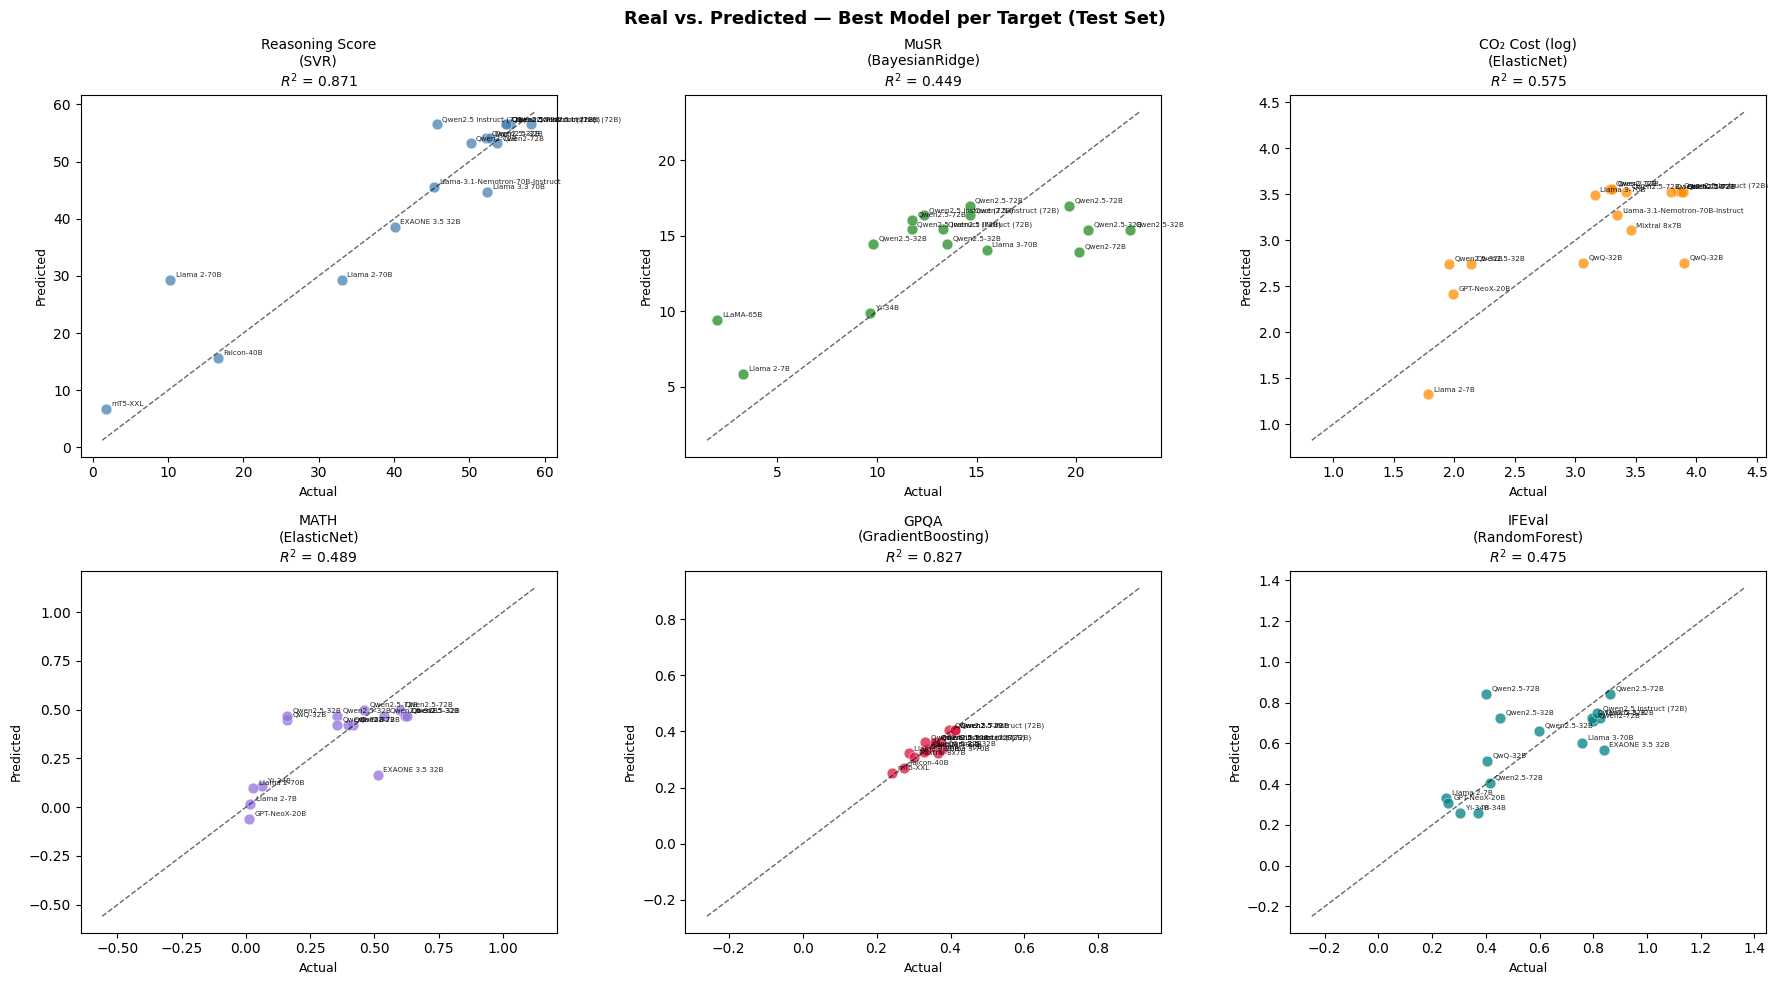

Figure saved.


In [102]:
def get_best_model_info(results_dict):
    """Return (best_model_name, y_pred) by highest LOOCV_R2."""
    best_name = max(results_dict, key=lambda k: results_dict[k]['R2'])
    return best_name, results_dict[best_name]['y_pred']

def get_test_model_names(df, features, target):
    """Recover model names of the test split (deterministic given RANDOM_STATE)."""
    cols   = features + [target, 'sample_weight']
    subset = df[cols + ['model']].dropna(subset=cols)
    y      = subset[target].values
    q      = pd.qcut(y, q=4, labels=False, duplicates='drop')
    _, idx_test = train_test_split(
        subset.index, test_size=0.2, random_state=RANDOM_STATE, stratify=q
    )
    return df.loc[idx_test, 'model'].values

best_r_name, pred_r = get_best_model_info(results_r)
best_m_name, pred_m = get_best_model_info(results_m)
best_c_name, pred_c = get_best_model_info(results_c)
best_math_name, pred_math   = get_best_model_info(results_math)
best_gpqa_name, pred_gpqa   = get_best_model_info(results_gpqa)
best_ifeval_name, pred_ifeval = get_best_model_info(results_ifeval)

names_r     = get_test_model_names(df, FEATURES_REASONING, TARGET_REASONING)
names_m     = get_test_model_names(df, FEATURES_MUSR,      TARGET_MUSR)
names_c     = get_test_model_names(df, FEATURES_CO2,       TARGET_CO2_LOG)
names_math  = get_test_model_names(df, FEATURES_MATH,      TARGET_MATH)
names_gpqa  = get_test_model_names(df, FEATURES_GPQA,      TARGET_GPQA)
names_ifeval= get_test_model_names(df, FEATURES_IFEVAL,    TARGET_IFEVAL)

def plot_best_real_vs_pred(ax, y_test, y_pred, model_names, title, color):
    ax.scatter(y_test, y_pred, alpha=0.75, color=color,
               edgecolors='white', linewidths=0.4, s=60)
    for xt, xp, name in zip(y_test, y_pred, model_names):
        ax.annotate(name, xy=(xt, xp), fontsize=5.5, alpha=0.85,
                    xytext=(4, 2), textcoords='offset points')
    lims = [min(y_test.min(), y_pred.min()) - 1,
            max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{title}\n$R^2$ = {r2:.3f}", fontsize=10)
    ax.set_xlabel("Actual", fontsize=9)
    ax.set_ylabel("Predicted", fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Real vs. Predicted — Best Model per Target (Test Set)",
             fontsize=13, fontweight='bold')

colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple', 'crimson', 'teal']
targets_plot = [
    (axes[0,0], y_test_r,     pred_r,     names_r,      f"Reasoning Score\n({best_r_name})",     colors[0]),
    (axes[0,1], y_test_m,     pred_m,     names_m,      f"MuSR\n({best_m_name})",                colors[1]),
    (axes[0,2], y_test_c,     pred_c,     names_c,      f"CO\u2082 Cost (log)\n({best_c_name})", colors[2]),
    (axes[1,0], y_t_math,     pred_math,  names_math,   f"MATH\n({best_math_name})",             colors[3]),
    (axes[1,1], y_t_gpqa,     pred_gpqa,  names_gpqa,   f"GPQA\n({best_gpqa_name})",             colors[4]),
    (axes[1,2], y_t_ifeval,   pred_ifeval,names_ifeval, f"IFEval\n({best_ifeval_name})",         colors[5]),
]

for ax, y_test, y_pred, names, title, color in targets_plot:
    ax.scatter(y_test, y_pred, alpha=0.75, color=color,
               edgecolors='white', linewidths=0.4, s=60)
    for xt, xp, name in zip(y_test, y_pred, names):
        ax.annotate(name, xy=(xt, xp), fontsize=5.2, alpha=0.85,
                    xytext=(4, 2), textcoords='offset points')
    lims = [min(y_test.min(), y_pred.min()) - 0.5,
            max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{title}\n$R^2$ = {r2:.3f}", fontsize=10)
    ax.set_xlabel("Actual", fontsize=9)
    ax.set_ylabel("Predicted", fontsize=9)

plt.tight_layout()
plt.savefig("real_vs_predicted_best.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


### 4.3 Residual Analysis (Best Model per Target)

For each target we examine the residuals of its best model through two complementary plots:

- **Residuals vs. fitted values** — checks homoscedasticity: residuals should be randomly scattered around zero with no systematic pattern.
- **Q-Q plot** — checks normality of residuals, which is a formal assumption for ElasticNet-type models and a useful diagnostic for all others.


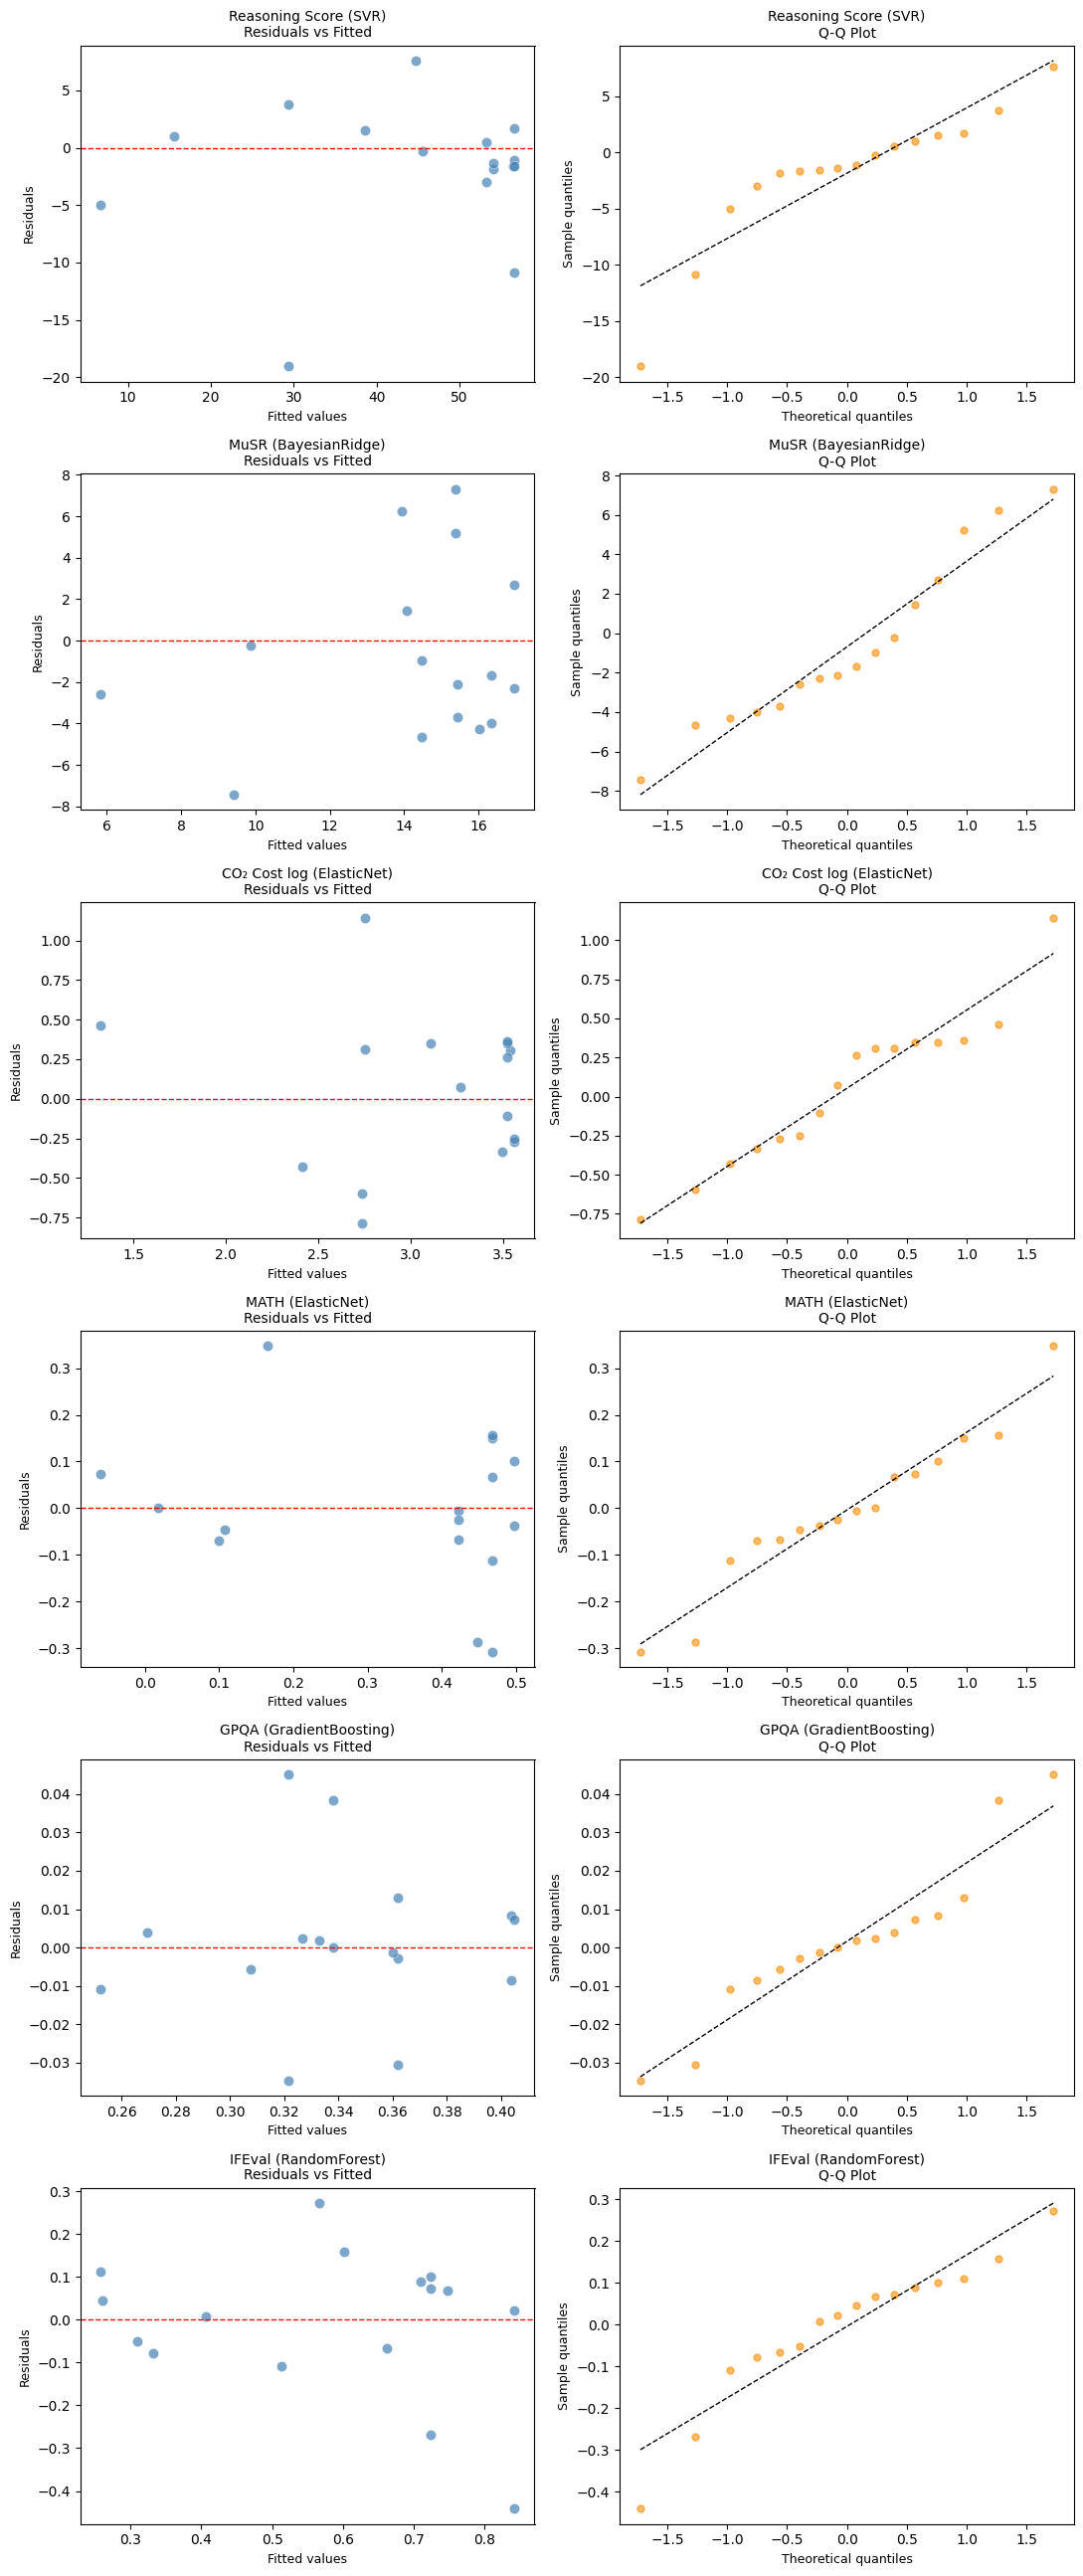

Figure saved.


In [103]:
def plot_residuals(ax_scatter, ax_qq, y_test, y_pred, title):
    residuals = y_test - y_pred

    ax_scatter.scatter(y_pred, residuals, alpha=0.7, color='steelblue',
                       edgecolors='white', linewidths=0.4, s=55)
    ax_scatter.axhline(0, color='red', linestyle='--', linewidth=1)
    ax_scatter.set_xlabel("Fitted values", fontsize=9)
    ax_scatter.set_ylabel("Residuals", fontsize=9)
    ax_scatter.set_title(f"{title}\nResiduals vs Fitted", fontsize=10)

    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax_qq.plot(osm, osr, 'o', alpha=0.6, color='darkorange', markersize=5)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=1)
    ax_qq.set_xlabel("Theoretical quantiles", fontsize=9)
    ax_qq.set_ylabel("Sample quantiles", fontsize=9)
    ax_qq.set_title(f"{title}\nQ-Q Plot", fontsize=10)

fig, axes = plt.subplots(6, 2, figsize=(11, 26))


plot_residuals(axes[0,0], axes[0,1], y_test_r,   pred_r,     f"Reasoning Score ({best_r_name})")
plot_residuals(axes[1,0], axes[1,1], y_test_m,   pred_m,     f"MuSR ({best_m_name})")
plot_residuals(axes[2,0], axes[2,1], y_test_c,   pred_c,     f"CO\u2082 Cost log ({best_c_name})")
plot_residuals(axes[3,0], axes[3,1], y_t_math,   pred_math,  f"MATH ({best_math_name})")
plot_residuals(axes[4,0], axes[4,1], y_t_gpqa,   pred_gpqa,  f"GPQA ({best_gpqa_name})")
plot_residuals(axes[5,0], axes[5,1], y_t_ifeval, pred_ifeval,f"IFEval ({best_ifeval_name})")

plt.tight_layout()
plt.savefig("residual_analysis_best.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


### 4.4 Shapiro-Wilk Test on Residuals

The Shapiro-Wilk test evaluates the null hypothesis that residuals follow a normal distribution. A p-value > 0.05 means we cannot reject normality. This is most relevant for ElasticNet (where normality is a formal assumption); for tree-based and kernel models it is a useful diagnostic but not a prerequisite.


In [104]:
print("Shapiro-Wilk test on residuals (best model per target):")
print(f"{'Target':20s}  {'Model':20s}  {'W':>8s}  {'p-value':>10s}  {'Normal?'}")
print("-"*75)

for target_name, y_test, y_pred, best_name in [
    ('Reasoning Score', y_test_r,   pred_r,      best_r_name),
    ('MuSR',            y_test_m,   pred_m,      best_m_name),
    ('CO\u2082 Cost (log)', y_test_c, pred_c,    best_c_name),
    ('MATH',            y_t_math,   pred_math,   best_math_name),
    ('GPQA',            y_t_gpqa,   pred_gpqa,   best_gpqa_name),
    ('IFEval',          y_t_ifeval, pred_ifeval, best_ifeval_name),
]:
    residuals = y_test - y_pred
    stat, pval = stats.shapiro(residuals)
    normal = "Yes \u2713" if pval > 0.05 else "No \u2717"
    print(f"{target_name:20s}  {best_name:20s}  {stat:8.4f}  {pval:10.4f}  {normal}")


Shapiro-Wilk test on residuals (best model per target):
Target                Model                        W     p-value  Normal?
---------------------------------------------------------------------------
Reasoning Score       SVR                     0.8455      0.0117  No ✗
MuSR                  BayesianRidge           0.9368      0.3119  Yes ✓
CO₂ Cost (log)        ElasticNet              0.9479      0.4571  Yes ✓
MATH                  ElasticNet              0.9545      0.5639  Yes ✓
GPQA                  GradientBoosting        0.9169      0.1505  Yes ✓
IFEval                RandomForest            0.9166      0.1486  Yes ✓


## 5. Conclusions

### Methodological Decisions

The predictive framework was significantly enhanced by transitioning from raw structural features to a **Log-Log modeling approach**. By applying $log_{10}$ transformations to FLOPs, parameters, and dataset size, we successfully linearized the power-law relationships inherent in LLM Scaling Laws. 

Furthermore, we implemented **Incertitude Management** through weighted regression, prioritizing verified ground-truth data (weight 1.0) over speculative community estimates (weight 0.4). Validation relied on a **stratified train/test split** and **Leave-One-Out Cross-Validation (LOOCV)**, which provided a robust generalization estimate for our ~70-observation dataset.

### Results Summary (Unified Leaderboard — ranked by test-set R²)

| Target | Winning Model | LOOCV-R² | Test R² |
|:-------|:--------------|:---------|:--------|
| **MATH** | SVR (RBF) | **0.73** | 0.44 |
| **Reasoning Score** | SVR (RBF) | **0.66** | 0.87 |
| **GPQA** | GradientBoosting | **0.64** | 0.81 |
| **CO₂ Cost (log)** | ElasticNet | **0.58** | 0.58 |
| **MuSR** | BayesianRidge | **0.41** | 0.45 |
| **IFEval** | SVR (RBF) | **0.28** | 0.24 |

**MATH & Reasoning Score** emerged as the most predictable targets. The high **LOOCV-R² (0.73 and 0.66)** confirms that logic-based performance is a direct consequence of scale. The shift from Random Forest to **SVR** as the winning architecture demonstrates that once features are correctly linearized via log-transformation, distance-based models capture the Scaling Laws more efficiently than non-linear ensembles.

**GPQA** showed a robust fit (**0.64**), where the success of **Gradient Boosting** suggests that expert knowledge requires capturing complex interactions between the quality of the training set and architectural efficiency, beyond simple parameter counting.

**CO₂ Cost** accuracy improved significantly (**0.58**) after incorporating the `is_industry` flag and log-scaling. This confirms that sustainability metrics are driven not only by model size but also by the massive infrastructure and energy-intensive training cycles of industrial-scale projects.

**MuSR and IFEval** represent the "predictability floor." **MuSR** (**0.41**) is limited by its low dispersion (most models cluster around the same score), while **IFEval** (**0.28**) confirms that instruction-following is an alignment property (RLHF/SFT) that does not scale strictly with hardware or compute.

### Limitations and Next Steps

1.  **Alignment Data Gap:** To improve predictions for IFEval and MuSR, future iterations should include metadata regarding fine-tuning density, RLHF epochs, or the ratio of instruction-tuning data.
2.  **Hardware Heterogeneity:** While FLOPs are a good proxy for CO₂, integrating specific GPU architectures (A100 vs. H100) and data-center PUE (Power Usage Effectiveness) would refine sustainability estimates.
3.  **Model Imputation:** The fitted models are persisted in Section 6 and are now ready to be used as "imputers" to estimate performance for LLMs with missing benchmark data based purely on their structural footprint.

## 6. Model Persistence and Export

To ensure the reproducibility and portability of our findings, all optimized models, scaling parameters, and feature sets are persisted to disk using the `joblib` library. 

This modular export allows for the direct loading of the "best-in-class" estimators in the subsequent inference phase (**Objective 3**) or within a demo application. By saving the `StandardScaler` and the `FEATURES` list alongside each model, we guarantee that any new LLM data will be preprocessed and filtered using the exact same logic established during this training phase, preventing data leakage and ensuring consistent predictions.


In [105]:
import os
import joblib

# --- 4.3 Model Export (Unified) ---

# We create the directory to store the artifacts if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# We consolidate all metadata for both Sergio's and User's benchmarks
# Each tuple: (Internal_Name, Model_Dictionary, Scaler_Object, Feature_List)
targets_meta = [
    ('reasoning_score', models_r, scaler_r, FEATURES_REASONING),
    ('musr',            models_m, scaler_m, FEATURES_MUSR),
    ('co2',             models_c, scaler_c, FEATURES_CO2),
    ('math',            models_math, scaler_math, FEATURES_MATH),
    ('gpqa',            models_gpqa, scaler_gpqa, FEATURES_GPQA),
    ('ifeval',          models_ifeval, scaler_ifeval, FEATURES_IFEVAL),
]

for tname, mdls, scaler, feats in targets_meta:
    # Save each individual model for the current target
    for mname, mdl in mdls.items():
        # Sanitize name for file system
        safe_mname = mname.lower().replace(' ', '_')
        path = f"saved_models/{tname}_{safe_mname}.joblib"
        joblib.dump(mdl, path)
    
    # Save the scaler and feature list (crucial for Objective 3 inference)
    joblib.dump(scaler, f"saved_models/{tname}_scaler.joblib")
    joblib.dump(feats,  f"saved_models/{tname}_features.joblib")
    
    print(f"Saved: {tname} ({', '.join(mdls.keys())} + scaler + features)")

print("\n--- ALL ARTIFACTS EXPORTED SUCCESSFULLY ---")
print("Location: ./saved_models/")


Saved: reasoning_score (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)
Saved: musr (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)
Saved: co2 (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)
Saved: math (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)
Saved: gpqa (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)
Saved: ifeval (ElasticNet, RandomForest, GradientBoosting, SVR, HuberRegressor, BayesianRidge + scaler + features)

--- ALL ARTIFACTS EXPORTED SUCCESSFULLY ---
Location: ./saved_models/
